<a href="https://colab.research.google.com/github/evgeny-kolonsky/Lab4/blob/main/PE/LED/lab4_pe_led_spectrum.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Photoelectric effect. LED measurements


0.1.0

0.2.0 Seven new diodes with measured spectrum

0.2.1 Observed band instead of nominal

# Resume



In [6]:
import numpy as np
import requests
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.constants import h, elementary_charge as e, speed_of_light as c
from urllib import request
import matplotlib

In [7]:
def wavelength_to_color(wavelength, gamma=0.8):
    ''' taken from http://www.noah.org/wiki/Wavelength_to_RGB_in_Python
    This converts a given wavelength of light to an
    approximate RGB color value. The wavelength must be given
    in nanometers in the range from 380 nm through 750 nm
    (789 THz through 400 THz).

    Based on code by Dan Bruton
    http://www.physics.sfasu.edu/astro/color/spectra.html
    '''
    wavelength = float(wavelength)
    if wavelength < 380:
        wavelength = 380.
    if wavelength > 750:
        wavelength = 750.
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 <= wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 <= wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 <= wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 <= wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 <= wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    else:
        R = 0.0
        G = 0.0
        B = 0.0
    r = int(R*255)
    g = int(G*255)
    b = int(B*255)
    return "#{:02x}{:02x}{:02x}".format(r, g, b)

# Measurements by optical spectroscope

First order $n=1$
$$ \lambda = d \sin\theta$$

In [1]:
d = 1e-3 / 500 # 500 lines per mm
data = '''
# band_nominal(from..to)[nm] thetas1(from..to)[deg]
500 510 13.88 16.01
390 395 11.38 12.41  # and weak green-red band 14.2 18.6
730 730 19.2 21.56
540 550 14.76 17.75
560 570 15.25 18.50
520 525 14.20 17.60
420 425 11.5 12.6
405 410 11.45 12.51
'''


In [51]:
import pandas as pd

# Parse the data string into a list of lists
data_rows = []
for line in data.strip().split('\n'):
    if not line.startswith('#'):
        parts = line.split()
        # Assuming structure: nominal_from, nominal_to, theta1_from, theta1_to
        data_rows.append([float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])])

# Create a DataFrame
df = pd.DataFrame(data_rows, columns=['nominal_from', 'nominal_to', 'theta1_from', 'theta1_to'])

# Convert degrees to radians
df['theta1_from_rad'] = np.deg2rad(df['theta1_from'])
df['theta1_to_rad'] = np.deg2rad(df['theta1_to'])

# Calculate observed wavelengths using the grating equation: lambda = d * sin(theta)
# The variable 'd' is defined in the previous cell (U6Tm3Q3ZnXYK)
df['observed_lambda_from_nm'] = d * np.sin(df['theta1_from_rad']) * 1e9 # Convert to nm
df['observed_lambda_to_nm'] = d * np.sin(df['theta1_to_rad']) * 1e9 # Convert to nm

# Calculate the average observed wavelength for labeling/color mapping if needed
df['observed_avg_nm'] = (df['observed_lambda_from_nm'] + df['observed_lambda_to_nm']) / 2

# Get a representative color for each observed band using the wavelength_to_color function
df['color'] = df['observed_avg_nm'].apply(wavelength_to_color)

display(df)

,nominal_from,nominal_to,theta1_from,theta1_to,theta1_from_rad,theta1_to_rad,observed_lambda_from_nm,observed_lambda_to_nm,observed_avg_nm,color
0,500.0,510.0,13.88,16.01,0.242252,0.279427,479.778368,551.610247,515.694307,#22ff00
1,390.0,395.0,11.38,12.41,0.198618,0.216595,394.630298,429.811571,412.220935,#6400ba
2,730.0,730.0,19.20,21.56,0.335103,0.376293,657.733293,734.950713,696.342003,#b60000
3,540.0,550.0,14.76,17.75,0.257611,0.309796,509.541451,609.728598,559.635025,#c1ff00
4,560.0,570.0,15.25,18.50,0.266163,0.322886,526.062429,634.609313,580.335871,#fffd00
5,520.0,525.0,14.20,17.60,0.247837,0.307178,490.614772,604.739782,547.677277,#9bff00
6,420.0,425.0,11.50,12.60,0.200713,0.219911,398.735869,436.286483,417.511176,#5b00c7
7,405.0,410.0,11.45,12.51,0.199840,0.218341,397.025426,433.220013,415.122719,#5f00c1


Now, let's visualize each diode's observed spectral band, stacked one above the other.

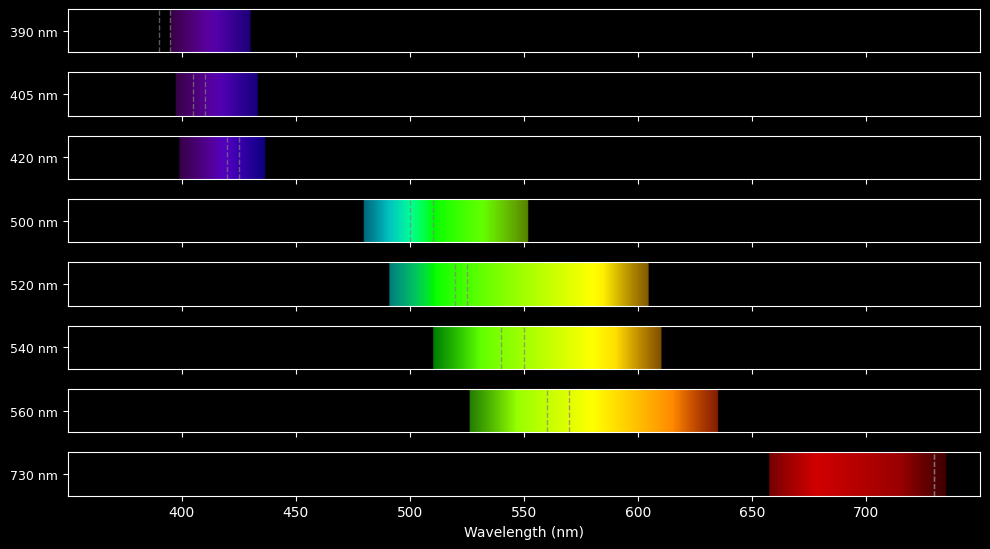

In [68]:
import pandas as pd

# Define the overall visible light range for consistent x-axis across plots
visible_light_range = (350, 750) # nm

# Sort the DataFrame by nominal_from wavelength
df_sorted = df.sort_values(by='nominal_from').reset_index(drop=True)

# Set up the figure with subplots for each diode
num_diodes = len(df_sorted)
fig, axs = plt.subplots(num_diodes, 1, figsize=(10, num_diodes * 0.7), tight_layout=True) # Increased height for better visibility
plt.style.use('dark_background') # Ensure dark background

# Adjust axs to be an iterable even if there's only one subplot
if num_diodes == 1:
    axs = [axs]

for i, (index, row) in enumerate(df_sorted.iterrows()):
    ax = axs[i]

    # Get the observed wavelength range for the current diode
    band_start = row['observed_lambda_from_nm']
    band_end = row['observed_lambda_to_nm']

    # Get the nominal wavelength range for the current diode
    nominal_start = row['nominal_from']
    nominal_end = row['nominal_to']

    # Generate a fine-grained array of wavelengths across the full visible spectrum
    wavelengths_full = np.linspace(visible_light_range[0], visible_light_range[1], 500)

    # Create a mask for the current diode's observed band
    observed_band_mask = (wavelengths_full >= band_start) & (wavelengths_full <= band_end)

    # Get RGB colors for each wavelength in the full range
    raw_rgb_colors_full = np.array([matplotlib.colors.to_rgb(wavelength_to_color(w)) for w in wavelengths_full])

    # Set colors outside the observed band to black
    filtered_rgb_colors_band = raw_rgb_colors_full.copy()
    filtered_rgb_colors_band[~observed_band_mask] = 0  # Explicitly black outside the band

    # Apply a blurred alpha channel to create smooth edges for the observed band
    # Use the nominal range for the blur kernel for now, can be adjusted
    blur_kernel_size_band = 50 # Increased for a more pronounced blur
    intensities_band = np.convolve(observed_band_mask.astype(float), np.ones(blur_kernel_size_band)/blur_kernel_size_band, mode='same')

    # Prepare RGBA image data for imshow
    band_height = 30 # Increased for better visibility
    image_rgb_data_band = np.repeat(filtered_rgb_colors_band[np.newaxis, :, :], band_height, axis=0)
    image_alpha_data_band = np.repeat(intensities_band[np.newaxis, :], band_height, axis=0)

    image_rgba_band = np.zeros((band_height, len(wavelengths_full), 4))
    image_rgba_band[:, :, :3] = image_rgb_data_band
    image_rgba_band[:, :, 3] = image_alpha_data_band

    # Plotting with imshow
    ax.imshow(image_rgba_band,
               extent=(visible_light_range[0], visible_light_range[1], 0, 1),
               aspect='auto')

    # Add gray lines for nominal values
    ax.axvline(nominal_start, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(nominal_end, color='gray', linestyle='--', linewidth=1, alpha=0.7)

    # Set x-axis limits and labels
    ax.set_xlim(visible_light_range[0], visible_light_range[1])
    ax.set_xticks(np.arange(400, 701, 50)) # Adjusted ticks from 400 to 700 with step 50

    # Set y-tick label with nominal value instead of subplot title
    ax.set_yticks([0.5]) # Place tick in the middle of the band
    ax.set_yticklabels([f'{nominal_start:.0f} nm'], color='white', fontsize=9)

    # Add x-axis label only to the bottom-most subplot
    if i == num_diodes - 1:
        ax.set_xlabel('Wavelength (nm)', color='white')
    else:
        ax.set_xticklabels([]) # Hide x-axis ticks for intermediate plots

# Removed plt.suptitle for overall title
plt.show()